### BI Walmart Analysis - Visualizations

In [1]:
import os
import snowflake.connector
from dotenv import load_dotenv

load_dotenv()

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:

conn = snowflake.connector.connect(
    account   = os.environ["SNOWFLAKE_ACCOUNT"],
    user      = os.environ["SNOWFLAKE_USER"],
    password  = os.environ["SNOWFLAKE_PASSWORD"],
    warehouse = "COMPUTE_WH",
    database  = "WALMART",
    schema    = "DBT_SDEPALMA",
    role      = "ACCOUNTADMIN",
)

cur = conn.cursor()
cur.execute("SELECT COUNT(*) FROM obt_walmart_sales")
print("Row count:", cur.fetchone()[0])

# cur.close()
# conn.close()

Row count: 421570


In [3]:
query = """
    select *
    from obt_walmart_sales
"""

cur.execute(query)
df = cur.fetch_pandas_all()
print("Rows:", len(df))
df.head()

Rows: 421570


,SALES_DATE,STORE_ID,DEPT_ID,WEEKLY_SALES,STORE_TYPE,STORE_SIZE,IS_HOLIDAY,TEMPERATURE,FUEL_PRICE,CPI,UNEMPLOYMENT,MARKDOWN1,MARKDOWN2,MARKDOWN3,MARKDOWN4,MARKDOWN5
0,2010-02-05,1,1,24924.50,A,151315,False,42.31,2.572,211.096358,8.106,NaN,NaN,NaN,NaN,NaN
1,2010-02-12,1,1,46039.49,A,151315,True,38.51,2.548,211.242170,8.106,NaN,NaN,NaN,NaN,NaN
2,2010-02-19,1,1,41595.55,A,151315,False,39.93,2.514,211.289143,8.106,NaN,NaN,NaN,NaN,NaN
3,2010-02-26,1,1,19403.54,A,151315,False,46.63,2.561,211.319643,8.106,NaN,NaN,NaN,NaN,NaN
4,2010-03-05,1,1,21827.90,A,151315,False,46.50,2.625,211.350143,8.106,NaN,NaN,NaN,NaN,NaN


In [4]:
df['YEAR'] = pd.to_datetime(df['SALES_DATE']).dt.year
df['MONTH'] = pd.to_datetime(df['SALES_DATE']).dt.month

##### 1. Weekly Sales by Store and Holiday

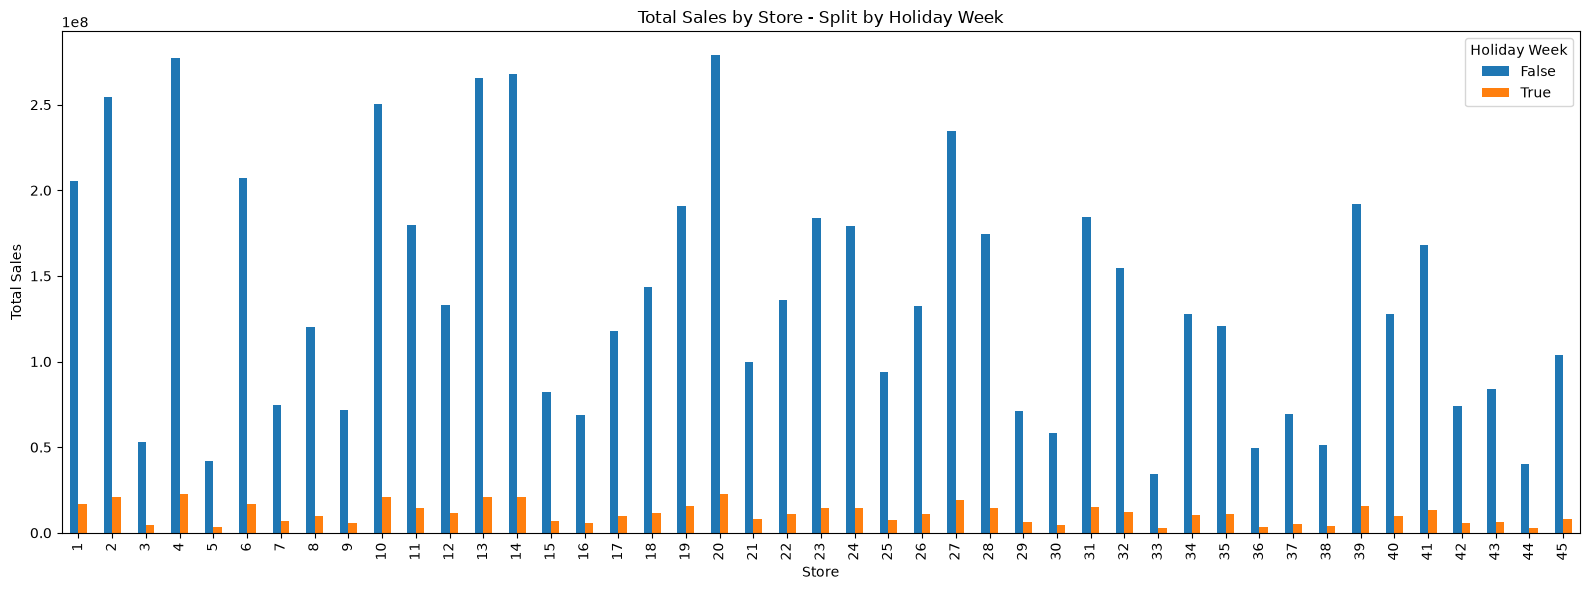

In [6]:
agg = (
    df.
    groupby(['STORE_ID', 'IS_HOLIDAY'])['WEEKLY_SALES'].sum()
    .reset_index()
)

pivot = agg.pivot(index='STORE_ID', columns='IS_HOLIDAY', values='WEEKLY_SALES')

pivot.plot(kind='bar', figsize=(16,6))
plt.title("Total Sales by Store - Split by Holiday Week")
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.legend(title='Holiday Week')
plt.tight_layout()

##### 2A. Weekly Sales by Temperature and Year (SUM of Sales)

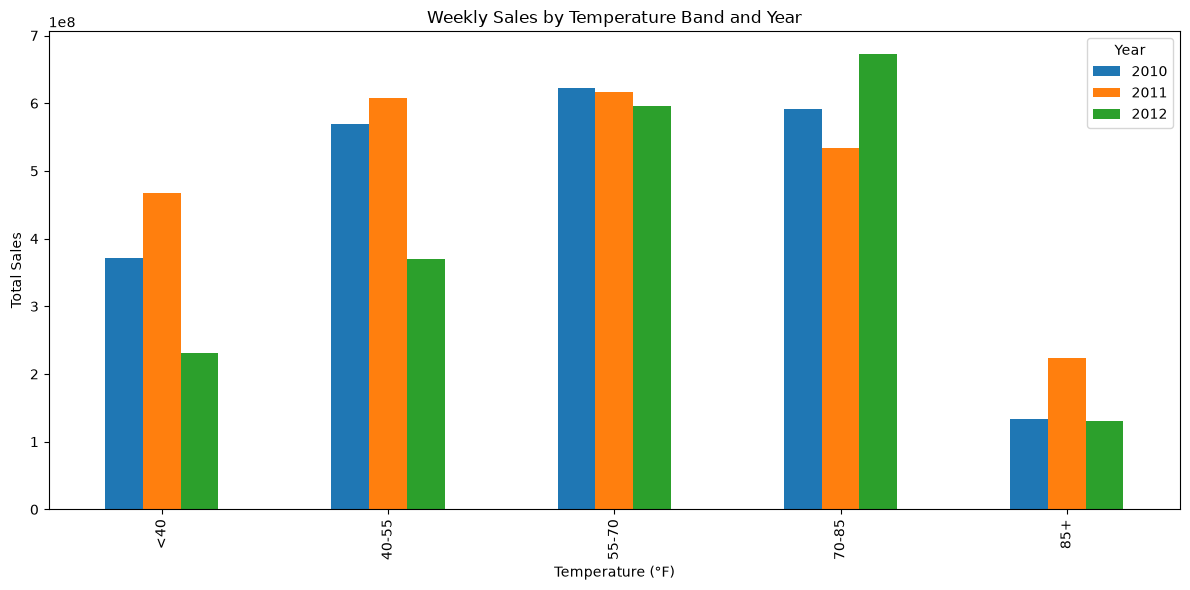

In [7]:
df['YEAR'] = pd.to_datetime(df['SALES_DATE']).dt.year

df['TEMP_BAND'] = pd.cut(df['TEMPERATURE'],
                         bins=[0, 40, 55, 70, 85, 120],
                         labels=['<40', '40-55', '55-70', '70-85', '85+'])

agg = (df.groupby(['TEMP_BAND', 'YEAR'], observed=True)['WEEKLY_SALES']
         .sum()
         .reset_index())

pivot = agg.pivot(index='TEMP_BAND', columns='YEAR', values='WEEKLY_SALES')

ax = pivot.plot(kind='bar', figsize=(12,6),
                title='Weekly Sales by Temperature Band and Year',
                xlabel='Temperature (°F)', ylabel='Total Sales')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

##### 2B. Weekly Sales by Temperature and Year (Normalized - Average Sales)

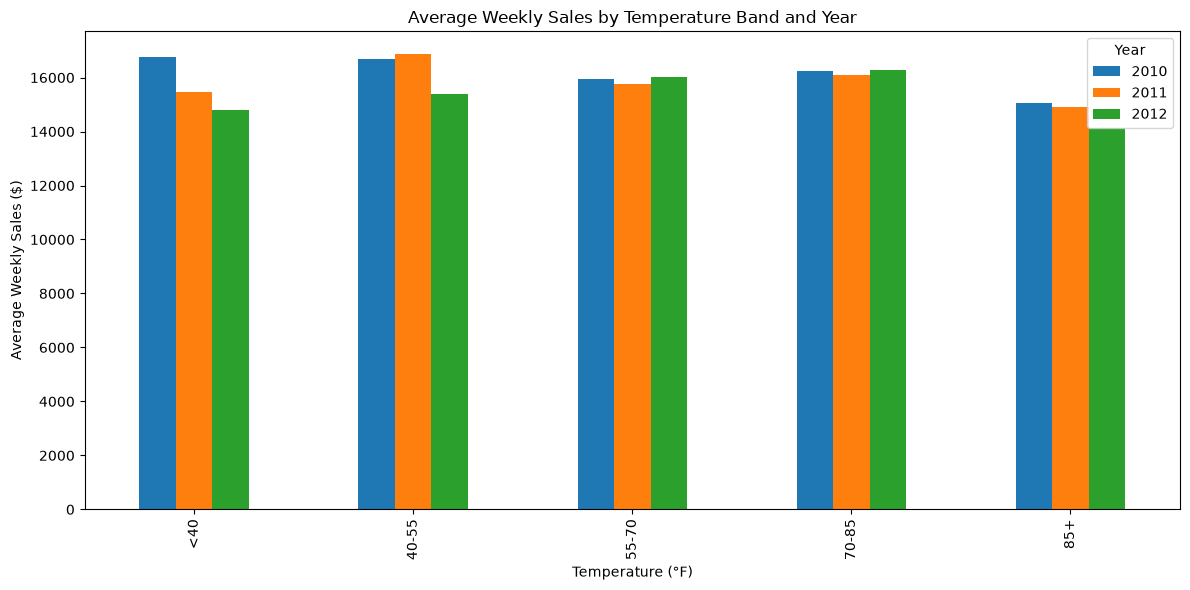

In [16]:
agg = (
    df.groupby(['TEMP_BAND', 'YEAR'], observed=True)
      .agg(
          AVG_WEEKLY_SALES=('WEEKLY_SALES', 'mean'),
          OBSERVATIONS=('WEEKLY_SALES', 'size')
      )
      .reset_index()
)

pivot = agg.pivot(
    index='TEMP_BAND',
    columns='YEAR',
    values='AVG_WEEKLY_SALES'
)

ax = pivot.plot(
    kind='bar',
    figsize=(12, 6),
    title='Average Weekly Sales by Temperature Band and Year',
    xlabel='Temperature (°F)',
    ylabel='Average Weekly Sales ($)'
)

plt.legend(title='Year')
plt.tight_layout()
plt.show()

##### 3. Total Sales by Store Size

<Axes: title={'center': 'Sales by Store Size'}, xlabel='size', ylabel='sales'>

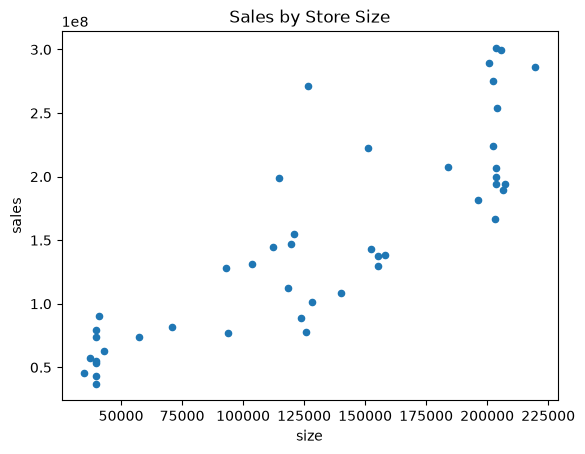

In [8]:
df.groupby('STORE_ID').agg(size=('STORE_SIZE','first'), sales=('WEEKLY_SALES','sum')).plot.scatter(x='size', y='sales', title='Sales by Store Size')

##### 4. Weekly Sales by Store Type and Month

<Axes: title={'center': 'Sales by Store Type and Month'}, xlabel='MONTH'>

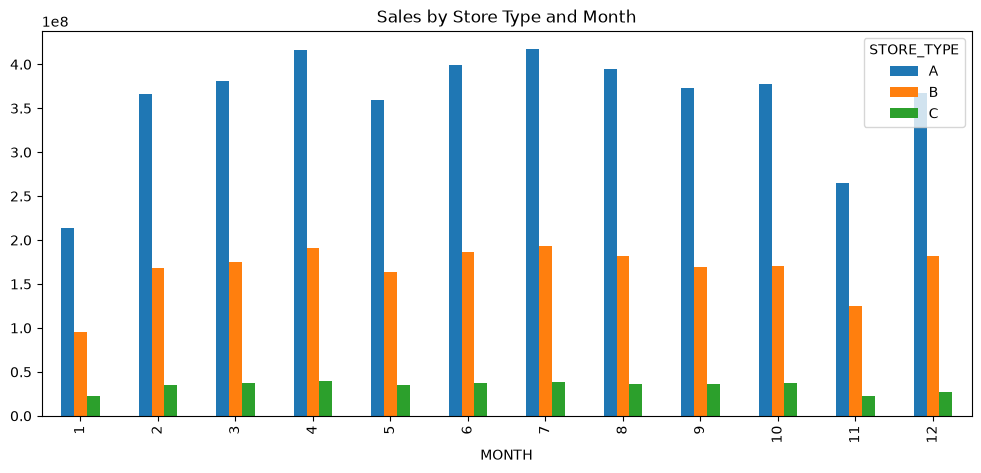

In [9]:
agg = df.groupby(['MONTH','STORE_TYPE'])['WEEKLY_SALES'].sum().reset_index()
agg.pivot(index='MONTH', columns='STORE_TYPE', values='WEEKLY_SALES').plot(kind='bar', figsize=(12,5), title='Sales by Store Type and Month')

##### 5. Markdown Sales by Year and Store

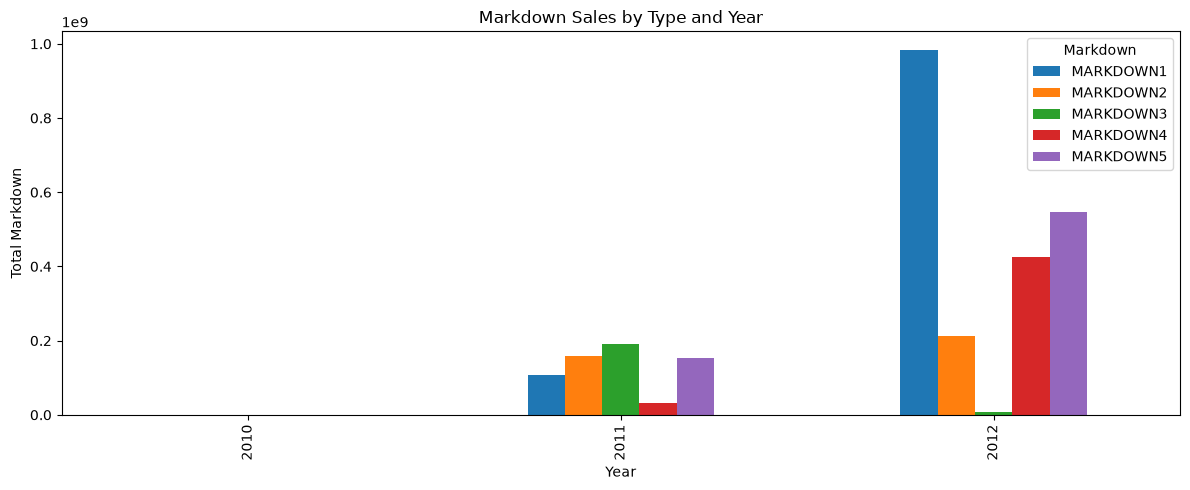

In [10]:
markdown_cols = ['MARKDOWN1','MARKDOWN2','MARKDOWN3','MARKDOWN4','MARKDOWN5']

agg = df.groupby('YEAR')[markdown_cols].sum()

agg.plot(kind='bar', figsize=(12,5),
         title='Markdown Sales by Type and Year',
         xlabel='Year', ylabel='Total Markdown')
plt.legend(title='Markdown')
plt.tight_layout()
plt.show()

##### 6. Weekly Sales by Store Type

<Axes: title={'center': 'Sales by Store Type'}, xlabel='STORE_TYPE'>

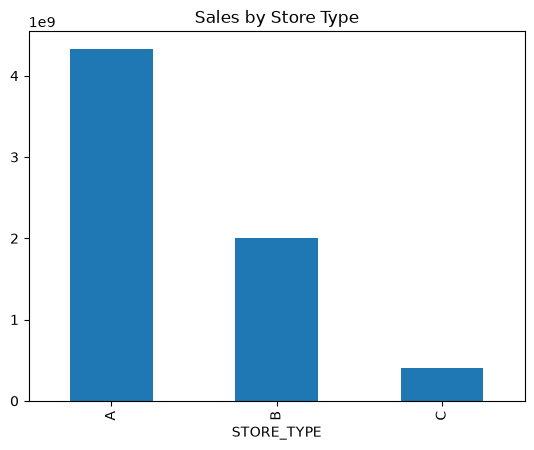

In [11]:
df.groupby('STORE_TYPE')['WEEKLY_SALES'].sum().plot(kind='bar', title='Sales by Store Type')

##### 7. Fuel Price by Year

<Axes: title={'center': 'Average Fuel Price by Year'}, xlabel='YEAR'>

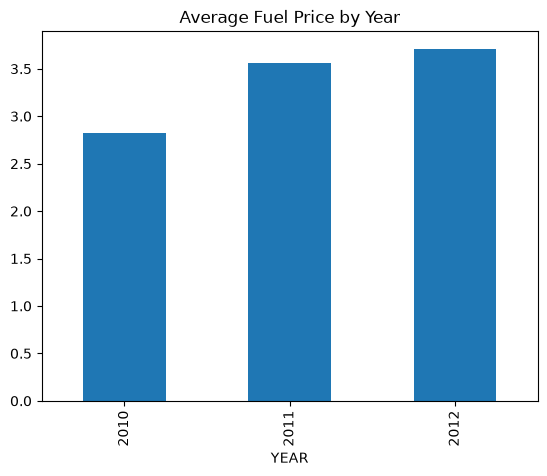

In [12]:
df.groupby('YEAR')['FUEL_PRICE'].mean().plot(kind='bar', title='Average Fuel Price by Year')

#### 8. Weekly Sales by Year, Month and Day

<Axes: title={'center': 'Weekly Sales Over Time'}, xlabel='SALES_DATE'>

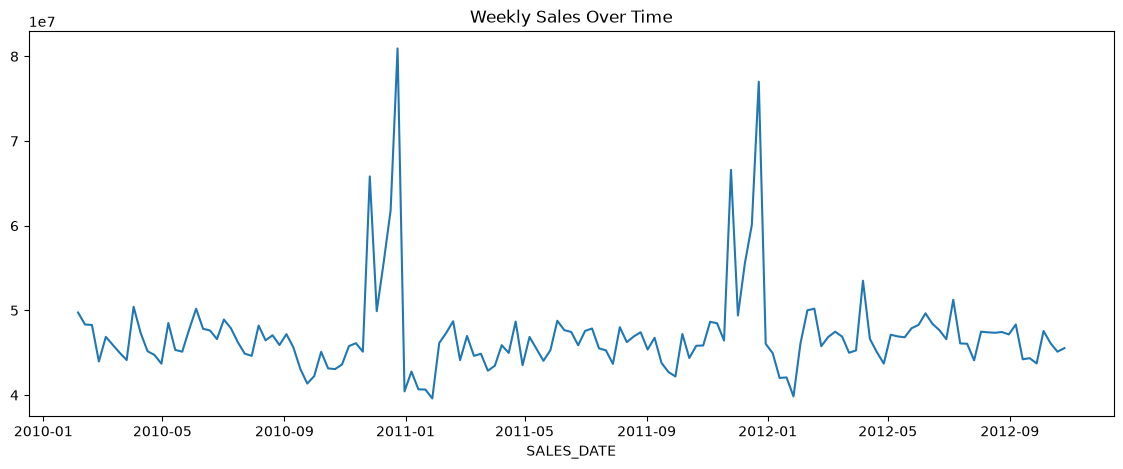

In [13]:
df.groupby('SALES_DATE')['WEEKLY_SALES'].sum().plot(figsize=(14,5), title='Weekly Sales Over Time')

#### 9. Weekly Sales by CPI

<Axes: title={'center': 'Weekly Sales vs CPI'}, xlabel='CPI', ylabel='WEEKLY_SALES'>

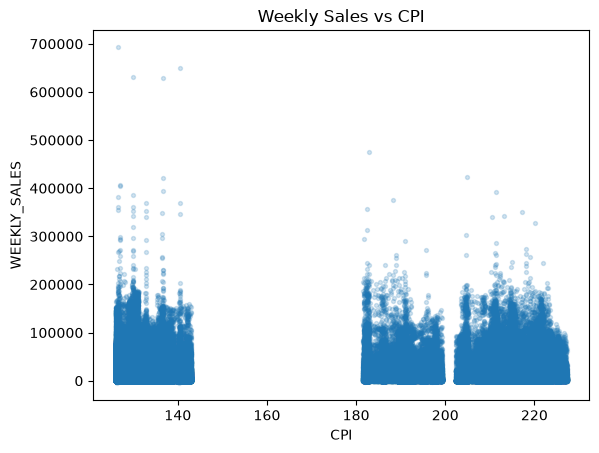

In [14]:
df.plot.scatter(x='CPI', y='WEEKLY_SALES', alpha=0.2, s=8, title='Weekly Sales vs CPI')

#### 10. Department-wise Weekly Sales

<Axes: title={'center': 'Sales by Department'}, xlabel='DEPT_ID'>

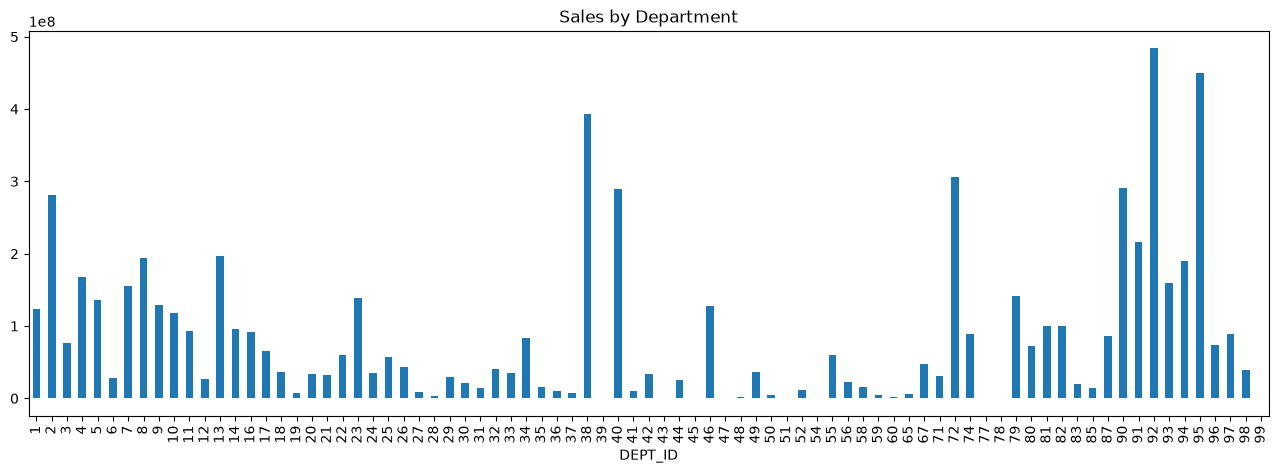

In [15]:
df.groupby('DEPT_ID')['WEEKLY_SALES'].sum().plot(kind='bar', figsize=(16,5), title='Sales by Department')